# Regression vs ComBat-Based Harmonisation

In this section, we compare regression-based harmonisation with ComBat-based harmonisation using simulated cross-sectional multi-site imaging data.

---

## Objectives

We will:

1. Simulate cross-sectional imaging data across multiple sites.
2. Introduce known:
   - additive batch effects (mean shifts),
   - multiplicative batch effects (variance differences).
3. Apply regression-based harmonisation.
4. Visualize the data before and after regression correction.
5. Apply ComBat/neuroHarmonize harmonisation.
6. Compare the harmonized results using visualizations and statistical evaluation.

---

## Why this matters

Scanner and site effects can introduce unwanted variability into imaging measurements.

These effects may appear as:
- systematic shifts in mean values across scanners,
- or differences in measurement variability across sites.

Simple regression approaches can often reduce additive mean shifts, but may not fully address multiplicative variance effects.

ComBat-like harmonisation methods are specifically designed to model and correct both:
- additive effects,
- and multiplicative effects,

while preserving biological variability associated with covariates of interest.

---

## Simulated Batch Effects

For demonstration purposes, the simulated batch effects in this example are intentionally exaggerated to make scanner/site-related effects easier to visualize and evaluate.

The simulated features include:

| Feature | Simulated effect |
|---|---|
| Feature_1 | additive effect only |
| Feature_2 | multiplicative effect only |
| Feature_3 | additive + multiplicative effects |
| Feature_4 | minimal/no batch effect |

---

## Expected observations

### After regression harmonisation
- additive site shifts should reduce,
- but variance differences may still remain.

### After ComBat/neuroHarmonize harmonisation
- both mean shifts and variance differences should reduce more effectively.

---

In [ ]:
# If needed
# %pip install neuroHarmonize nibabel neuroCombat

In [6]:
# Load packages

import pandas as pd


from block2_utils.HarmonisationEvaluation_functions import (
    simulate_cross_sectional_harmonization_data,
)
from block2_utils.HarmonisationEvaluation_plots import (
    plot_additive_multiplicative_effects,
)
from block2_utils.HarmonisationEvaluation_plots import plot_before_after_by_site
from neuroHarmonize import harmonizationLearn

   Subject   Age    Site  Feature_1  Feature_2  Feature_3  Feature_4
0        1  56.5  Site_C      948.4     1698.0     2264.6     2391.0
1        2  68.0  Site_B     1369.4     1407.7     1658.3     2249.5
2        3  59.6  Site_C      951.2     1634.0     1911.2     2371.8
3        4  64.8  Site_A     1236.7     1732.8     1980.8     2424.6
4        5  54.9  Site_B     1402.8     1705.7     1847.4     2277.0


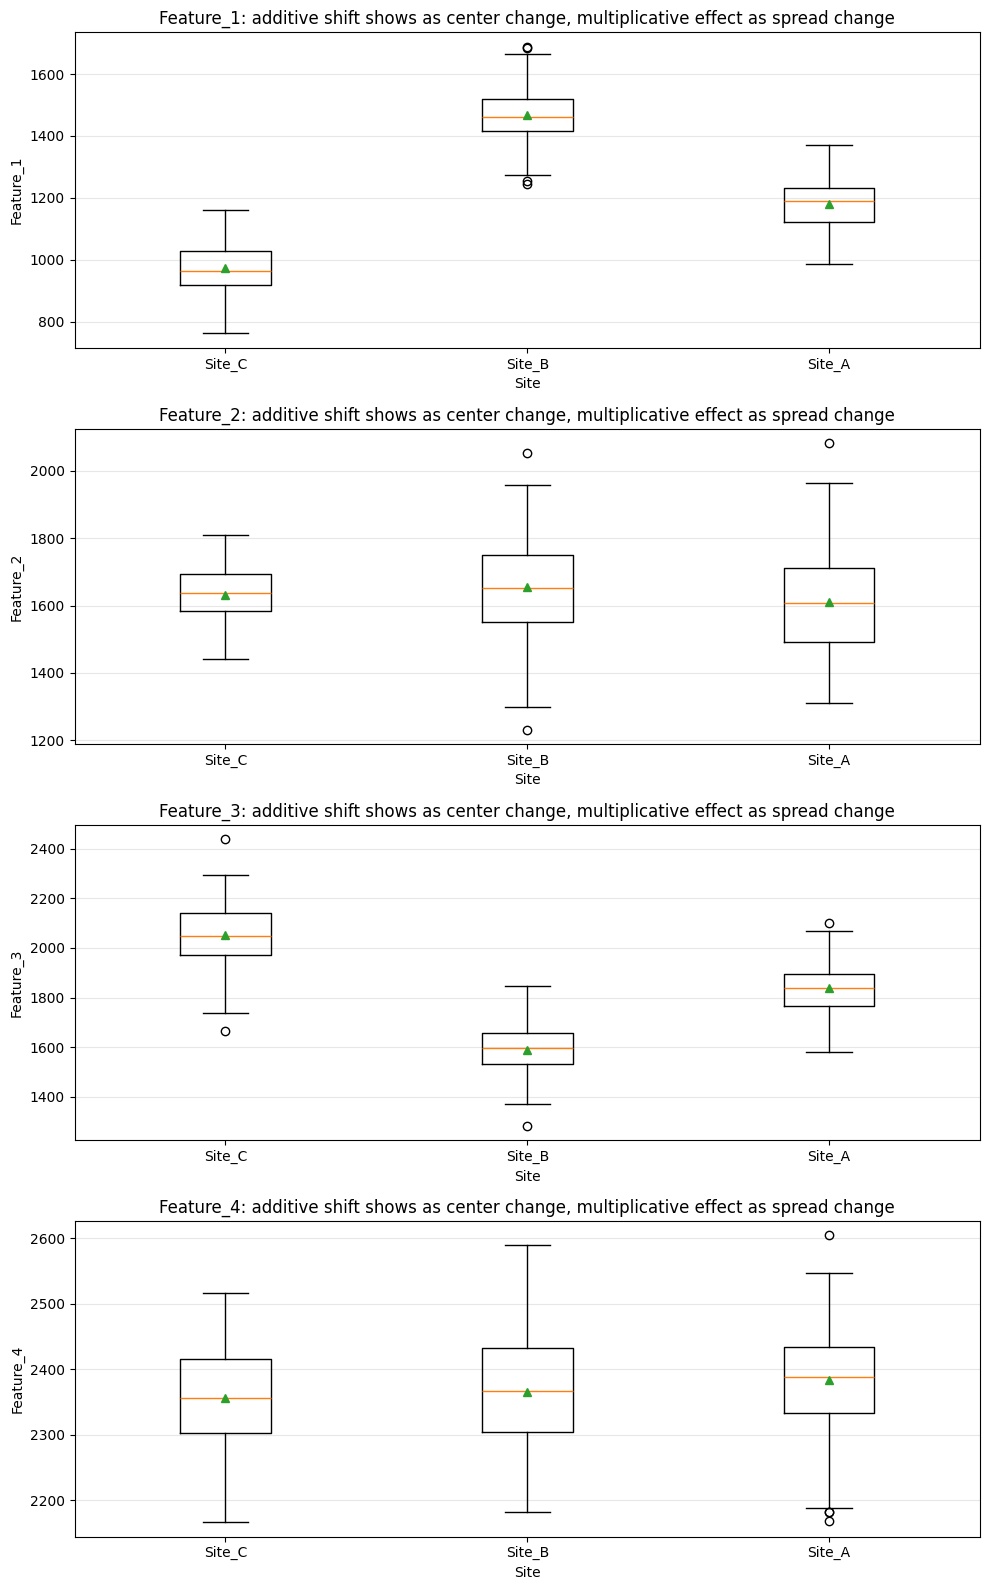

In [7]:
# Generate simulated data

# Define known site effects
# -----------------------------
# Simulated batch effects
# -----------------------------

# Feature_1 -> additive only
# Feature_2 -> multiplicative only
# Feature_3 -> additive + multiplicative
# Feature_4 -> no batch effect
n_subjects=300
n_sites=3
n_features=4
seed=1
additive_shift = {
    "Site_B": {
        "Feature_1": 300,
        "Feature_3": -250,
    },
    "Site_C": {
        "Feature_1": -200,
        "Feature_3": 220,
    },
}

multiplicative_scale = {
    "Site_A": {
        "Feature_2": 7.0,
        "Feature_3": 3.0,
    },
    "Site_B": {
        "Feature_2": 6.8,
        "Feature_3": 3.5,
    },
    "Site_C": {
        "Feature_2": 0.3,
        "Feature_3": 5.5,
    },
}

df = simulate_cross_sectional_harmonization_data(
    n_subjects=n_subjects,
    n_sites=n_sites,
    n_features=n_features,
    seed=seed,
    additive_shift=additive_shift,
    multiplicative_scale=multiplicative_scale,
)
print(df.head())

features = [f"Feature_{i}" for i in range(1, n_features + 1)]

#Plot additive and multiplicative effects
plot_additive_multiplicative_effects(df, feature_cols=features, batch_col="Site")


Model Summary
     Feature                    Formula   Site_pvalue        R2
0  Feature_1  Feature_1 ~ Age + C(Site)  1.132386e-77  0.872862
1  Feature_2  Feature_2 ~ Age + C(Site)  1.778094e-02  0.028970
2  Feature_3  Feature_3 ~ Age + C(Site)  4.758890e-42  0.752549
3  Feature_4  Feature_4 ~ Age + C(Site)  2.732957e-02  0.114791
   Subject   Age    Site  Feature_1  Feature_2  Feature_3  Feature_4  \
0        1  56.5  Site_C      948.4     1698.0     2264.6     2391.0   
1        2  68.0  Site_B     1369.4     1407.7     1658.3     2249.5   
2        3  59.6  Site_C      951.2     1634.0     1911.2     2371.8   
3        4  64.8  Site_A     1236.7     1732.8     1980.8     2424.6   
4        5  54.9  Site_B     1402.8     1705.7     1847.4     2277.0   

   Feature_1_harm  Feature_2_harm  Feature_3_harm  Feature_4_harm  
0     1171.984199     1697.920601     2052.005787     2400.625053  
1     1112.330975     1385.165375     1890.028471     2254.501029  
2     1179.444709     1634.08

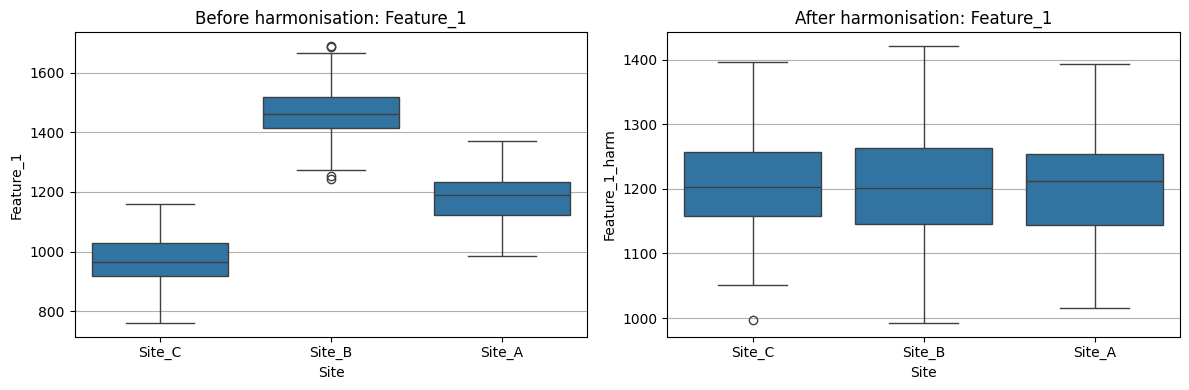

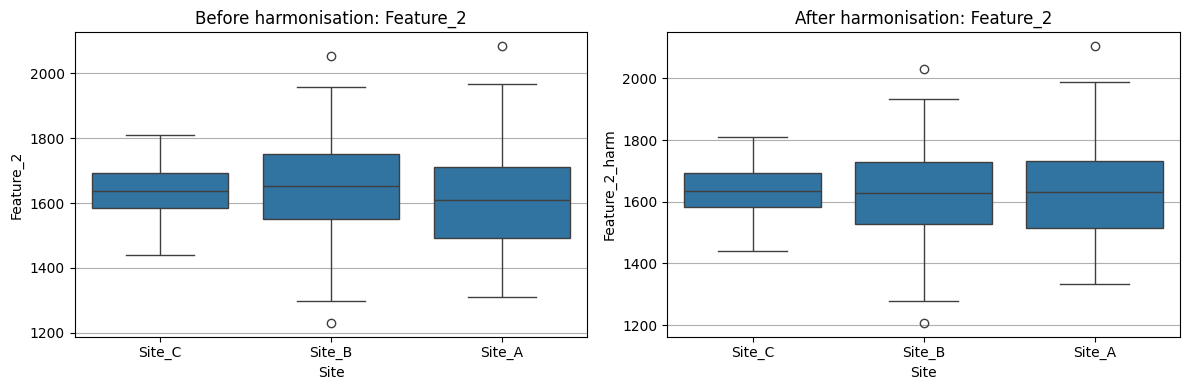

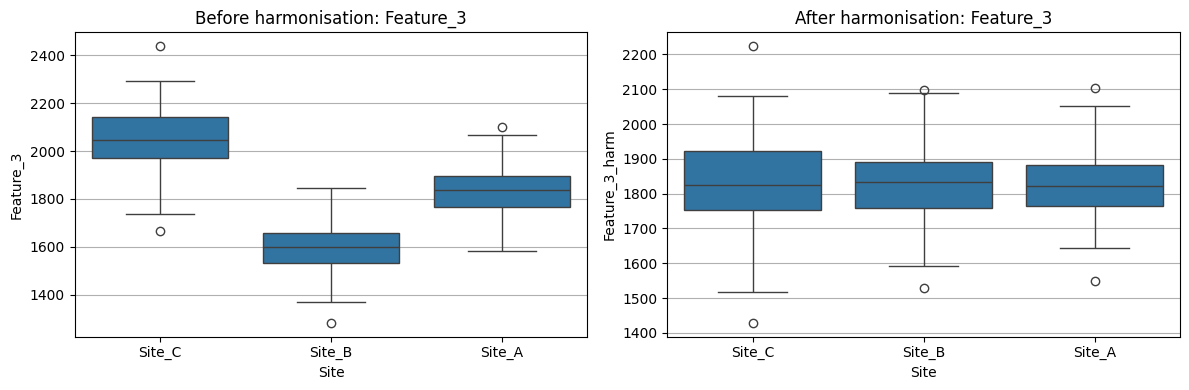

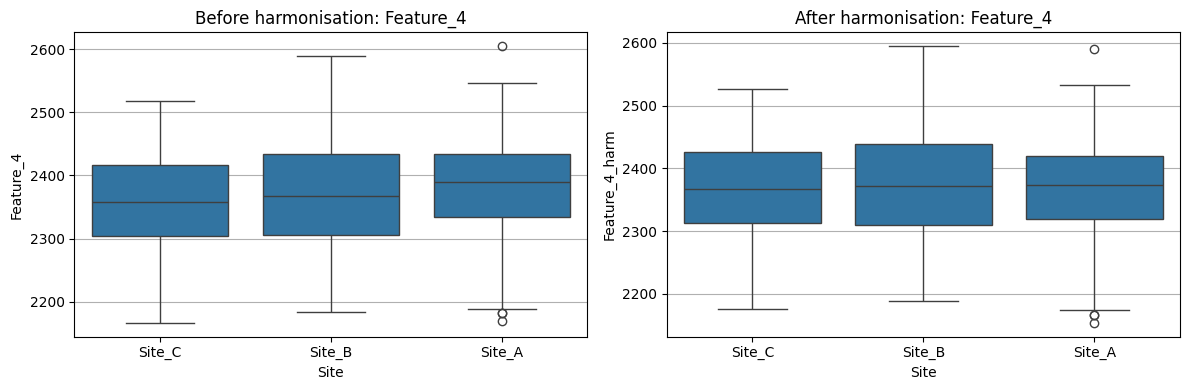

In [8]:
# Harmonise "Site/Batch" using regression
from block2_utils.HarmonisationEvaluation_functions import regression_harmonize_site

features = [f"Feature_{i}" for i in range(1, n_features + 1)]

df_harm, model_summary = regression_harmonize_site(
    df, feature_cols=features, site_col="Site", covariates=("Age", "Timepoint")
)
print("==" * 40)
print("Model Summary")
print(model_summary)
print("==" * 40)
print(df_harm.head())
plot_before_after_by_site(df_harm, features)

   Subject   Age    Site  Feature_1  Feature_2  Feature_3  Feature_4  \
0        1  56.5  Site_C      948.4     1698.0     2264.6     2391.0   
1        2  68.0  Site_B     1369.4     1407.7     1658.3     2249.5   
2        3  59.6  Site_C      951.2     1634.0     1911.2     2371.8   
3        4  64.8  Site_A     1236.7     1732.8     1980.8     2424.6   
4        5  54.9  Site_B     1402.8     1705.7     1847.4     2277.0   

   Feature_1_harm  Feature_2_harm  Feature_3_harm  Feature_4_harm  
0     1184.111864     1726.471789     2007.349130     2407.099135  
1     1109.920866     1415.224545     1899.596468     2263.610672  
2     1186.886636     1630.055202     1712.982216     2384.872901  
3     1259.904773     1743.115037     1987.893596     2412.672437  
4     1143.966770     1678.972066     2100.665324     2285.619012  


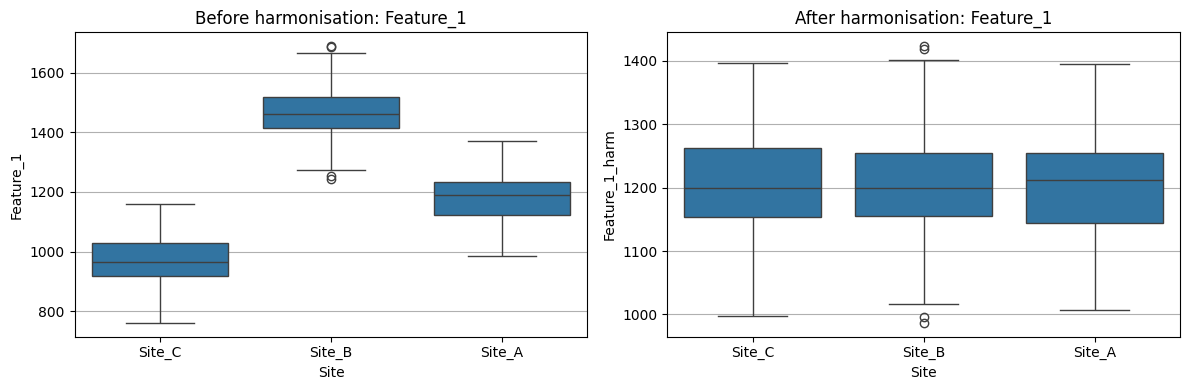

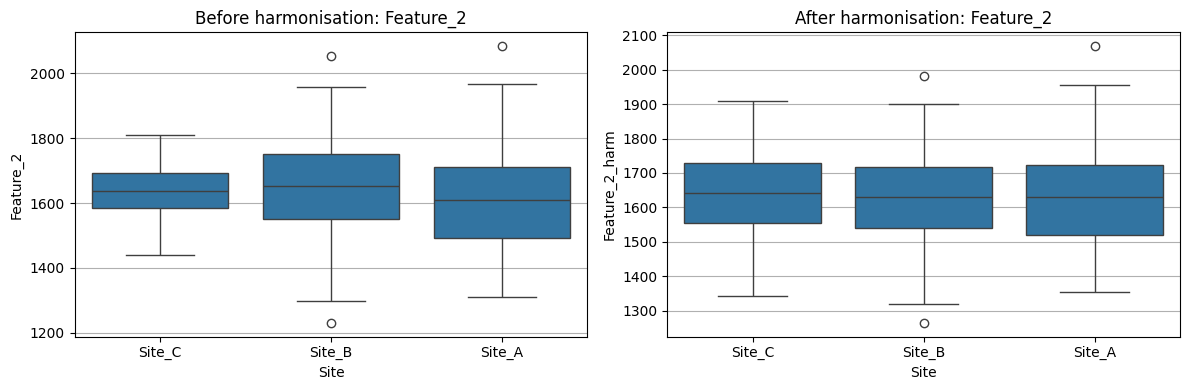

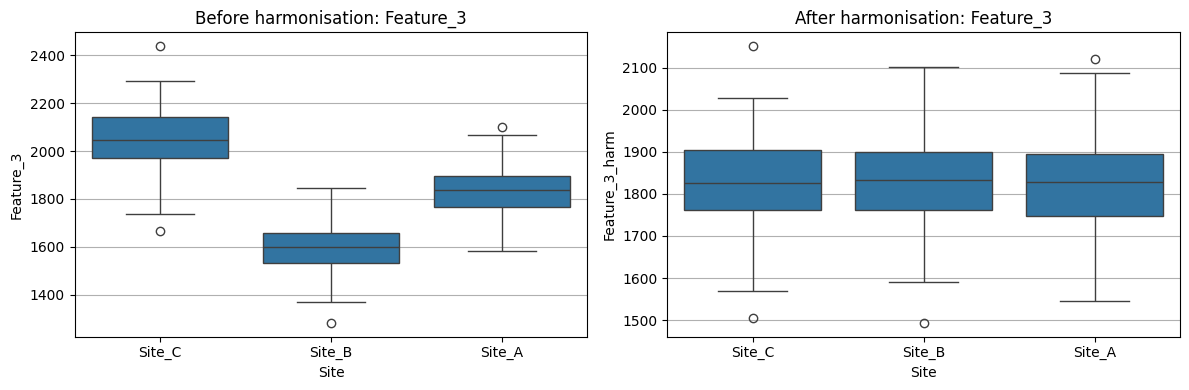

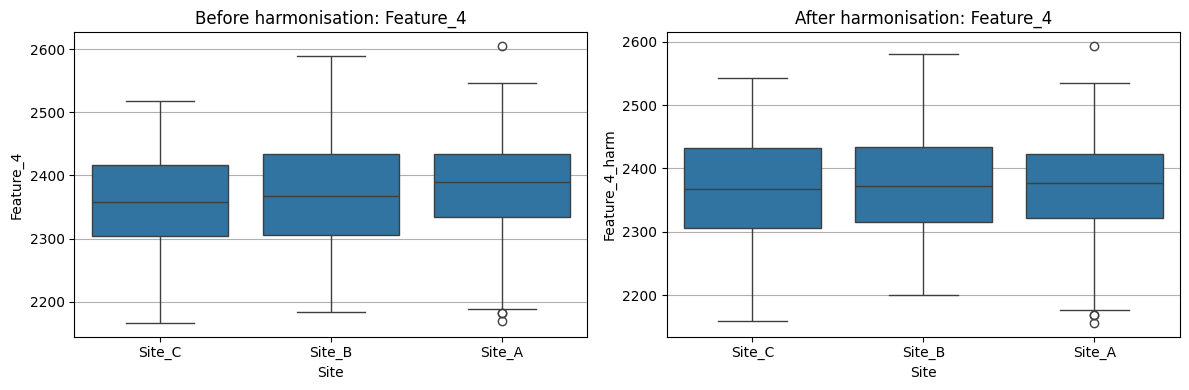

In [9]:
# Harmonise "Site/Batch" using ComBat
features = [f"Feature_{i}" for i in range(1, n_features + 1)]

# original feature matrix
data = df[features].to_numpy()

# covariates dataframe
covars = pd.DataFrame({"SITE": df["Site"], "Age": df["Age"]})

# harmonize
model, data_harm = harmonizationLearn(data, covars)

# convert harmonized matrix to dataframe
df_harm = pd.DataFrame(data_harm, columns=[f"{c}_harm" for c in features])

# combine with original dataframe
df_combined = pd.concat(
    [df.reset_index(drop=True), df_harm.reset_index(drop=True)], axis=1
)
print("==" * 40)
print(df_combined.head())
print("==" * 40)

# Plot additive and multiplicative effects after combat
plot_before_after_by_site(df_combined, features)

---
## Exercise

Modify the simulation to include:
- more imaging regions/features,
- different combinations of additive and multiplicative batch effects,
- or additional sites/scanners.

Then:

1. Apply regression-based harmonisation.
2. Apply ComBat/neuroHarmonize harmonisation.
3. Compare the results visually and statistically.

### Questions

- Which regions improved most after regression harmonisation?
- Which regions still showed residual variance differences?
- Did ComBat-based harmonisation further reduce batch effects?
- Which simulated effects were easiest or hardest to correct?

### Solution

You can check the solutions of this notebook [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block02)

- Feature 1: No site-related mean difference; ComBat reduced between-site variance differences.
- Feature 2: Site regression corrected the site-related mean difference; ComBat corrected both mean and variance differences.

---

Site Regression Additive effect:
          Feature      TestStat  df  p-value method
0  Feature_2_harm  5.875795e-28   1      1.0   Wald
1  Feature_1_harm  1.440366e-28   1      1.0   Wald
Site Regression Multiplicative effect:
          Feature      ChiSq  DF       p-value   method
0  Feature_1_harm  35.794151   1  2.193053e-09  Fligner
1  Feature_2_harm   2.421919   1  1.196483e-01  Fligner
ComBat Additive effect:
          Feature  TestStat  df   p-value method
0  Feature_2_harm  0.014845   1  0.903024   Wald
1  Feature_1_harm  0.009330   1  0.923051   Wald


ComBat Multiplicative effect:


          Feature     ChiSq  DF   p-value   method
0  Feature_1_harm  1.168476   1  0.279715  Fligner
1  Feature_2_harm  0.927320   1  0.335560  Fligner
['Feature_1', 'Feature_2']


Before and after Regression:




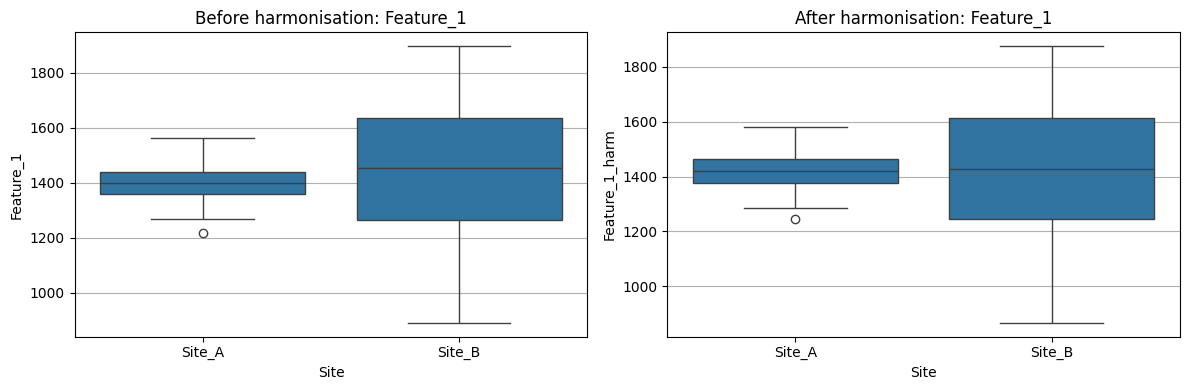

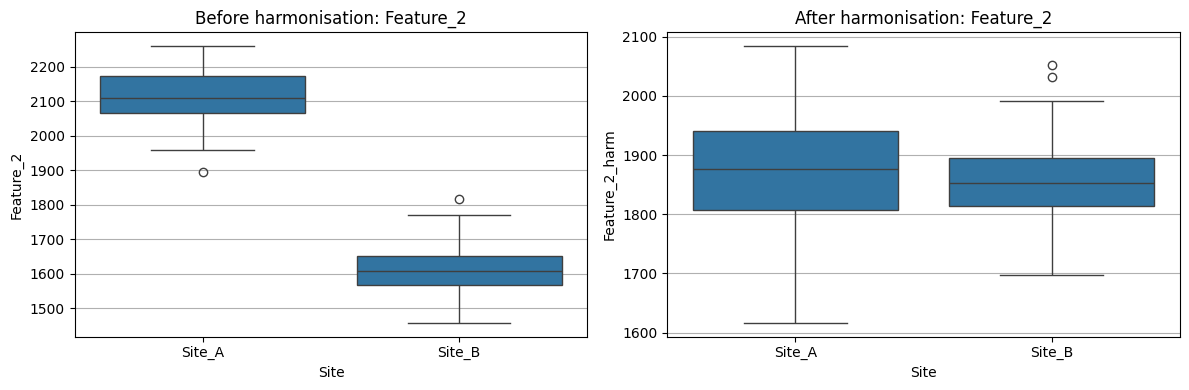



Before and after ComBat:




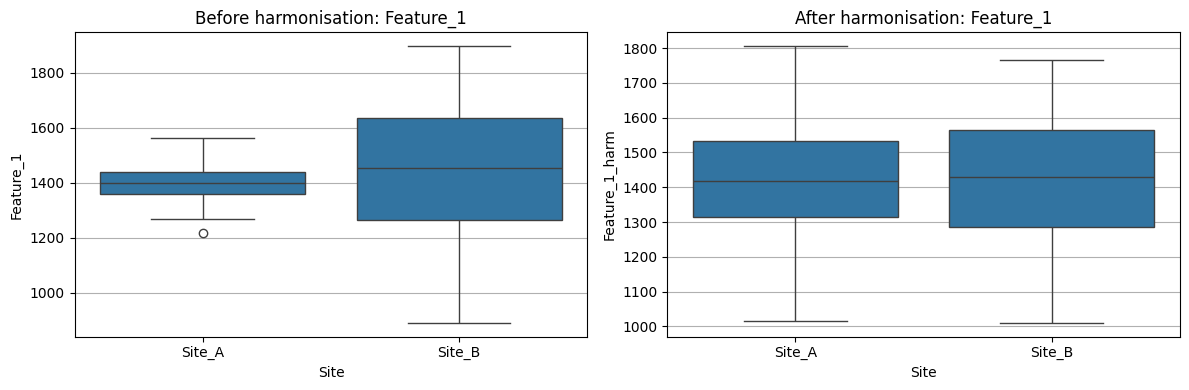

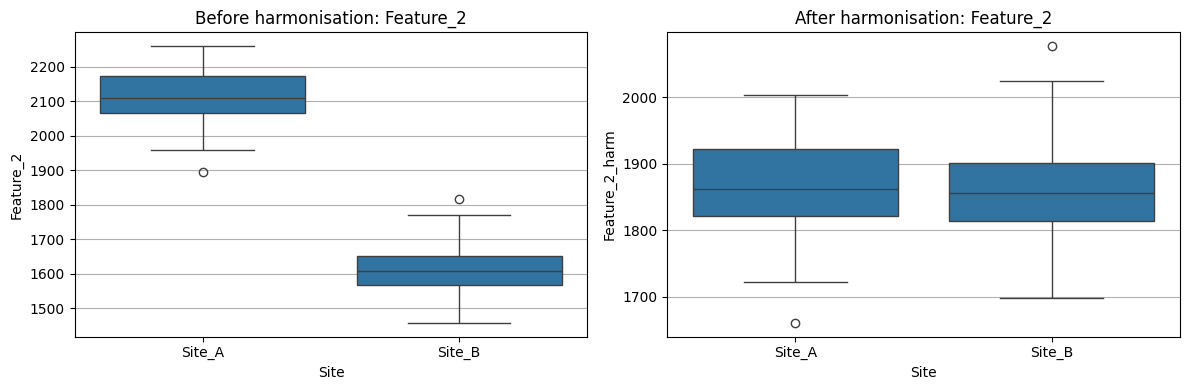

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from block2_utils.HarmonisationEvaluation_functions import (
    simulate_cross_sectional_harmonization_data,
    AdditiveEffect_long,
    MultiplicativeEffect_long,
    regression_harmonize_site,
)
from block2_utils.HarmonisationEvaluation_plots import plot_before_after_by_site

######## Simulate new data ########
n_subjects=100
n_sites=2
n_features=2
seed=1
additive_shift = {"Site_B": {"Feature_1": 20, "Feature_2": -500}}
multiplicative_scale = {"Site_B": {"Feature_1": 15.0}, "Site_A": {"Feature_2": 2.7}}

df = simulate_cross_sectional_harmonization_data(
    n_subjects=n_subjects,
    n_sites=n_sites,
    n_features=n_features,
    seed=seed,
    additive_shift=additive_shift,
    multiplicative_scale=multiplicative_scale,
)
feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

####### Site/Batch Regression ###########
df_reg_harm_full, model_summary = regression_harmonize_site(
    df, feature_cols=feature_cols, site_col="Site", covariates=("Age",)
)
reg_harm_feature_cols = [f"Feature_{i}_harm" for i in range(1, n_features + 1)]
regression_additive_results = AdditiveEffect_long(
    data=df_reg_harm_full,
    idp_names=reg_harm_feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar=None,
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print("Site Regression Additive effect:")
print(regression_additive_results)

regression_multiplicative_results = MultiplicativeEffect_long(
    data=df_reg_harm_full,
    idp_names=reg_harm_feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar=None,
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)

print("Site Regression Multiplicative effect:")
print(regression_multiplicative_results)

###### ComBat harmonisation #########
features = [f"Feature_{i}" for i in range(1, n_features + 1)]

data = df[features].to_numpy()
covars = pd.DataFrame({
    "SITE": df["Site"],
    "Age": df["Age"]
})

model, data_harm = harmonizationLearn(data, covars)

df_combat_harm = pd.DataFrame(
    data_harm,
    columns=[f"{c}_harm" for c in features]
)
# keep original features too
df_combat = pd.concat(
    [
        df[["Subject", "Site", "Age"]].reset_index(drop=True),
        df[features].reset_index(drop=True),
        df_combat_harm.reset_index(drop=True),
    ],
    axis=1,
)

combat_feature_cols = [f"Feature_{i}_harm" for i in range(1, n_features + 1)]

combat_additive_results = AdditiveEffect_long(
    data=df_combat,
    idp_names=combat_feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar=None,
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print("ComBat Additive effect:")
print(combat_additive_results)
combat_multiplicative_results = MultiplicativeEffect_long(
    data=df_combat,
    idp_names=combat_feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar=None,
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print("\n\nComBat Multiplicative effect:\n\n")
print(combat_multiplicative_results)

# Visualise
print(feature_cols)

print("\n\nBefore and after Regression:\n\n")
plot_before_after_by_site(df_reg_harm_full, feature_cols)

print("\n\nBefore and after ComBat:\n\n")
plot_before_after_by_site(df_combat, feature_cols)



# Longitudinal ComBat Harmonisation

Standard ComBat methods were originally developed for cross-sectional data, where each subject contributes a single observation.

In longitudinal studies, however, subjects are measured repeatedly over time.  
These repeated measurements introduce within-subject correlations that should be accounted for during harmonisation.

---

## What does longitudinal ComBat do?

Longitudinal ComBat extends the ComBat framework by incorporating subject-level random effects within a mixed-effects modeling framework.

This allows the method to:
- model repeated measurements from the same subject,
- preserve longitudinal biological trajectories,
- and estimate additive and multiplicative batch effects more appropriately for longitudinal data.

---

## Conceptual difference from standard ComBat

### Standard ComBat
Primarily models:

$$
y_{ij} = \alpha_j + \beta_j X_i + \gamma_{b(i)j} + \delta_{b(i)j}\epsilon_{ij}
$$

where:
- $\gamma$ represents additive batch effects,
- $\delta$ represents multiplicative batch effects.

This assumes observations are independent.

---

### Longitudinal ComBat
Adds subject-level random effects:

$$
y_{ij}(t) =
\alpha_j + \beta_j X_i(t)
+ u_i
+ \gamma_{b(i)j}
+ \delta_{b(i)j}\epsilon_{ij}
$$

where:
- $u_i$ represents subject-specific random effects,
- repeated measurements within subjects are explicitly modeled.

This helps preserve within-subject longitudinal structure during harmonisation.

---

## Current Implementation

At present, longitudinal ComBat is primarily available through an R implementation.

One commonly used implementation is:

- **longCombat (R package)**  
  https://github.com/jcbeer/longCombat

Python packages such as:
- `neuroCombat`
- `neuroHarmonize`

mainly implement standard (cross-sectional) ComBat approaches.

---

## Key Takeaway

For longitudinal imaging studies, explicitly modeling repeated subject measurements is important for reliable harmonisation.

Longitudinal ComBat extends standard ComBat by accounting for within-subject dependence while still correcting additive and multiplicative scanner/site effects.